In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import time
import matplotlib.pyplot as plt

from river import ensemble
from river import metrics
from river import preprocessing
from river import forest

In [ ]:
from pathlib import Path

dataset_name = "youtube_static.csv"
data_file = Path("../data/filtered") / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"], index_col="DATE")
print("Loaded:", data_file)

In [3]:
horizon = 96
split_point = int(len(df) * 0.8)
test_start_time = df.index[split_point]

model = preprocessing.StandardScaler() | forest.ARFRegressor(n_models=20,max_features=0.5,grace_period=100,
                                                            max_depth=5,seed=42)

records = []

total_training_time = 0.0
total_inference_time = 0.0
test_prediction_count = 0
train_sample_count = 0

for t in range(horizon, len(df) - horizon):

    # Prediction
    if df.index[t] >= test_start_time:
        start_pred = time.time()

    for h in range(1, horizon + 1):
        idx = t + h
        row = df.iloc[idx]
        x = {col: row[col] for col in df.columns if col not in ['mac_dl_brate', 'ue_ident']}
        pred = model.predict_one(x)
        actual = row['mac_dl_brate']
        timestamp = df.index[idx]
        source_t = df.index[t]

        records.append({
            'timestamp': timestamp,
            'source_t': source_t,
            'horizon': h,
            'actual': actual,
            'prediction': pred
        })

    if df.index[t] >= test_start_time:
        end_pred = time.time()
        total_inference_time += (end_pred - start_pred)
        test_prediction_count += horizon  

    # Training 
    if df.index[t + 1] < test_start_time:
        start_train = time.time()
        row = df.iloc[t + 1]
        x = {col: row[col] for col in df.columns if col not in ['mac_dl_brate', 'ue_ident']}
        y = row['mac_dl_brate']
        model.learn_one(x, y)
        end_train = time.time()
        total_training_time += (end_train - start_train)
        train_sample_count += 1

df_forecasts = pd.DataFrame(records)

print(f"Total training time: {total_training_time:.2f} seconds")
if train_sample_count > 0:
    avg_training_time = total_training_time / train_sample_count
    print(f"Average training time per sample: {avg_training_time:.6f} seconds")

print(f"Total inference time (test set): {total_inference_time:.2f} seconds")
if test_prediction_count > 0:
    avg_inference_time = total_inference_time / test_prediction_count
    print(f"Average inference time per test sample: {avg_inference_time:.6f} seconds")

Total training time: 62.11 seconds
Average training time per sample: 0.002375 seconds
Total inference time (test set): 100.01 seconds
Average inference time per test sample: 0.000161 seconds


In [4]:
print('Total training and inference time', avg_training_time + avg_inference_time)

Total training and inference time 0.0025357536976820323


In [5]:
df_test_forecasts = df_forecasts[df_forecasts['source_t'] >= test_start_time]

train_actuals = df_forecasts[df_forecasts['source_t'] < test_start_time]['actual']
scaler = MinMaxScaler()
scaler.fit(train_actuals.values.reshape(-1, 1))

actual_scaled = scaler.transform(df_test_forecasts['actual'].values.reshape(-1, 1)).flatten()
pred_scaled = scaler.transform(df_test_forecasts['prediction'].values.reshape(-1, 1)).flatten()

rmse = np.sqrt(mean_squared_error(actual_scaled, pred_scaled))
mae = mean_absolute_error(actual_scaled, pred_scaled)

print(f"Scaled RMSE: {rmse:.4f}")
print(f"Scaled MAE: {mae:.4f}")

Scaled RMSE: 0.0166
Scaled MAE: 0.0123


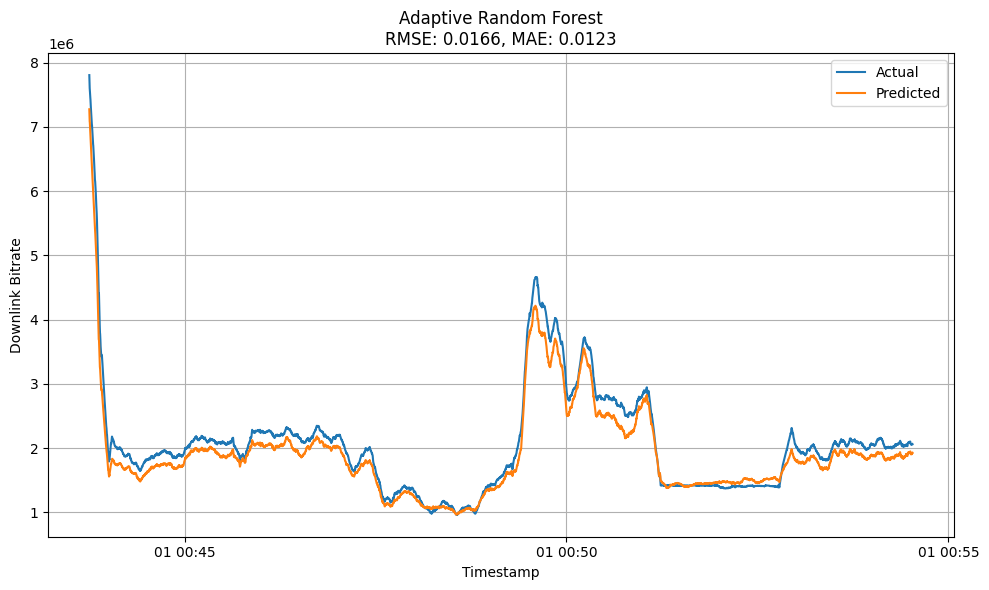

In [6]:
df_agg = df_test_forecasts.groupby('source_t').agg({
    'actual': 'mean',
    'prediction': 'mean'
}).dropna().reset_index()

df_agg['source_t'] = pd.to_datetime(df_agg['source_t'])

plt.figure(figsize=(10, 6))
plt.plot(df_agg['source_t'], df_agg['actual'], label='Actual')
plt.plot(df_agg['source_t'], df_agg['prediction'], label='Predicted')
plt.title(f'Adaptive Random Forest\nRMSE: {rmse:.4f}, MAE: {mae:.4f}')
plt.xlabel('Timestamp')
plt.ylabel('Downlink Bitrate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
results_dir = Path("../results/metrics")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "ARF",
    "setting": "multivariate",
    "dataset": "youtube_static",
    "rmse": rmse,
    "mae": mae,
}])

metrics_file = results_dir / "arf_multi_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)